# STAT 207 Group Lab Assignment 11 - [10 total points]

## Logistic Regression

<hr>

## <u>Lab Grading</u>:

Should we grade your submission?  If not, write the netID of the submission to be graded.  (Note: We will only grade one assignment per group, and we'll pick the first one that says we should grade that submission.  We will assign the same grade to all team members.)

*For example*, you might respond: **grade this submission** or **my submission is under netID jdeeke**

grade my submission

If you said **my submission is under netID** above, we will not read any more of your lab submission.

If you said **grade this submission** above, who worked with you on this submission?  Write both their **names** and **netIDs**.  

Also, discuss and record if you follow the NBA + your favorite NBA team, if you have one.

- Colin Richardson - colinhr3
- I don't have a favorite NBA team

<hr>

## <u>Purpose</u>:
You should work in groups of 2-3 on this report (not working in groups without permission will result in a point deduction). The purpose of this group lab assignment is to fit and use a logistic regression model.
<hr>

## <u>Assignment Instructions</u>:

### Group Roles

Suggested and specified roles are provided below: 

#### Groups of 2

* **Driver**: This student will type the report.  While typing the report, you may be the one who is selecting the functions to apply to the data.
* **Navigator**: This student will guide the process of answering the question.  Specific ways to help may include: outlining the general steps needed to solve a question (providing the overview), locating examples within the course notes, and reviewing each line of code as it is typed.

#### Groups of 3

* **Driver**: This student will type the report.  They may also be the one to select the functions to apply to the data.
* **Navigator**: This student will guide the process of answering the question.  They may select the general approach to answering the question and/or a few steps to be completed along the way. 
* **Communicator**: This student will review the report (as it is typed) to ensure that it is clear and concise.  This student may also locate relevant examples within the course notes that may help complete the assignment.

<hr>

### Imports

In [74]:
#Run this
import pandas as pd                    # imports pandas and calls the imported version 'pd'
import matplotlib.pyplot as plt        # imports the package and calls it 'plt'
import seaborn as sns                  # imports the seaborn package with the imported name 'sns'
sns.set()  

## Case Study: Understanding NBA Longevity

We will look at data collected on rookies in the NBA from 1980-2016 to determine if the rookies are successful and still playing in the NBA after 5 years.  The available variables include the following **per game** statistics:

- **GP**: number of games played
- **MIN**: number of minutes played per game
- **PTS**: number of points scored per game
- **FGM**: number of field goals made per game
- **FGA**: number of field goals attempted per game
- **FG%**: percentage of field goals made per game
- **3P Made**: number of 3-point field goals made per game
- **3PA**: number of 3-point field goals attempted per game
- **3P%**: percentage of 3-point field goals made per game
- **FTM**: number of free throws made per game
- **FTA**: number of free throws attempted per game
- **FT%**: percentage of free throws made per game
- **OREB**: number of offensive rebounds per game
- **DREB**: number of defensive rebounds per game
- **REB**: total number of rebounds per game
- **AST**: number of assists per game
- **STL**: number of steals per game
- **BLK**: number of blocks per game
- **TOV**: number of turnovers per game
- **TARGET_5Yrs**: whether the player is still playing in the NBA after 5 years (1 = playing, 0 = not playing)

The code cell below will read in the data for you.  Be sure to run the cell. 

In [75]:
df = pd.read_csv('nba_rookie.csv')

In [76]:
df

,Name,GP,MIN,PTS,FGM,FGA,FG_Perc,3P Made,3PA,3P_Perc,...,FTA,FT_Perc,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,Chris Smith,80,15.8,4.3,1.6,3.6,43.3,0.0,0.2,14.3,...,1.5,79.2,0.4,0.8,1.2,2.5,0.6,0.2,0.8,0
1305,Brent Price,68,12.6,3.9,1.5,4.1,35.8,0.1,0.7,16.7,...,1.0,79.4,0.4,1.1,1.5,2.3,0.8,0.0,1.3,1
1306,Marlon Maxey,43,12.1,5.4,2.2,3.9,55.0,0.0,0.0,0.0,...,1.6,64.3,1.5,2.3,3.8,0.3,0.3,0.4,0.9,0
1307,Litterial Green,52,12.0,4.5,1.7,3.8,43.9,0.0,0.2,10.0,...,1.8,62.5,0.2,0.4,0.7,2.2,0.4,0.1,0.8,1


### 1. [5.5 points] Fit a Logistic Regression Model

**a)** Fit a model predicting whether the player lasts 5 years or more in the NBA from four of the other variables in the data.  You may pick the combination of four variables to use as predictors.

In [77]:
import statsmodels.formula.api as smf

log_model = smf.logit("TARGET_5Yrs ~ GP + PTS + BLK + FTM", data = df).fit()
log_model.summary()

Optimization terminated successfully.
         Current function value: 0.551103
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            TARGET_5Yrs   No. Observations:                 1309
Model:                          Logit   Df Residuals:                     1304
Method:                           MLE   Df Model:                            4
Date:                Wed, 06 Nov 2024   Pseudo R-squ.:                  0.1640
Time:                        12:03:44   Log-Likelihood:                -721.39
converged:                       True   LL-Null:                       -862.93
Covariance Type:            nonrobust   LLR p-value:                 4.856e-60
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.6286      0.234    -11.218      0.000      -3.088      -2.169
GP             0.0397      0.004      8.841      0.000       0.031       0.048
PTS            0.0354      0.039      0.917      0.359      -0.040       0.111
BLK            0.6042      0.210      2.873      0.004       0.192       1.016
FTM            0.3615      0.178      2.033      0.042       0.013       0.710
==============================================================================
"""

**b)** What is the pseudo-$R^2$ for this model?  

In [78]:
log_model.prsquared

0.1640163175112176

**c)** In general, what is the pseudo-$R^2$ measuring?  In other words, what one ideal quality of a model is measured with this number?

This value shows that a larger value is indicative of a better model strength, with a maximum value of 1, and increases as we add more predictors. Since this value is relatively low, less than 0.5, it shows us that the variables that we chose, although more than one, are not good predictors when it comes to predicting whether the player lasts 5 years or more in the NBA.

**d)** Interpret the coefficient fit for one of the predictor variables in terms of the **odds**.

In [79]:
import numpy as np
import math

x = 0.0397
odds = (math.e)**x
odds

1.040498577791932

**e)** What are the baseline odds for the fitted model?

odds of playing 5 more years = -2.6286 + e^(0.0397) + e^(0.0354) + e^(0.6042) + e^(0.3615)

### 2. [2 points] Ayo Donsunmu

One of the most recent players in the NBA from the University of Illinois is Ayo Donsunmu.  

**a)** Use the NBA Regular Season Stats per game for the 2021-2022 season (Ayo's rookie season) from this website https://basketball.realgm.com/player/Ayo-Dosunmu/Summary/107970 to predict the probability that Ayo will last in the NBA for at least 5 years.

In [80]:
import statsmodels.formula.api as smf

log_model = smf.logit("TARGET_5Yrs ~ GP + PTS + BLK + FTM", data = df).fit()
log_model.summary()

Optimization terminated successfully.
         Current function value: 0.551103
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            TARGET_5Yrs   No. Observations:                 1309
Model:                          Logit   Df Residuals:                     1304
Method:                           MLE   Df Model:                            4
Date:                Wed, 06 Nov 2024   Pseudo R-squ.:                  0.1640
Time:                        12:03:44   Log-Likelihood:                -721.39
converged:                       True   LL-Null:                       -862.93
Covariance Type:            nonrobust   LLR p-value:                 4.856e-60
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.6286      0.234    -11.218      0.000      -3.088      -2.169
GP             0.0397      0.004      8.841      0.000       0.031       0.048
PTS            0.0354      0.039      0.917      0.359      -0.040       0.111
BLK            0.6042      0.210      2.873      0.004       0.192       1.016
FTM            0.3615      0.178      2.033      0.042       0.013       0.710
==============================================================================
"""

In [81]:
probs = log_model.predict(exog=dict(
    GP = 77,
    PTS = 8.8,
    BLK = 0.4,
    FTM = 0.7
))
probs

0    0.774132
dtype: float64

**b)** Based on the available observations in the dataset, does this prediction seem trustworthy?  Briefly explain.

*Hint*: there are two ways that you can answer this question, both of which compare Ayo's characteristics to those in the available data.

In [82]:
df_sample = df[(df['GP'] > 77) & (df['PTS'] > 8.8) & (df['BLK'] > 0.4) & (df['FTM'] > 0.7)]
sample = df.sample(1)
gp = sample['GP']
pts = sample['PTS']
blk = sample['BLK']
ftm = sample['FTM']

probs2 = log_model.predict(exog=dict(
    GP = gp,
    PTS = pts,
    BLK = blk,
    FTM = ftm
))
probs2

1205    0.810703
dtype: float64

In [83]:
df_sample = df[(df['GP'] < 77) & (df['PTS'] < 8.8) & (df['BLK'] < 0.4) & (df['FTM'] < 0.7)]
sample = df.sample(1)
gp = sample['GP']
pts = sample['PTS']
blk = sample['BLK']
ftm = sample['FTM']

probs3 = log_model.predict(exog=dict(
    GP = gp,
    PTS = pts,
    BLK = blk,
    FTM = ftm
))
probs3

60    0.16449
dtype: float64

The data tells us that the predictors we are using cannot accurately tell us if a player is going to play in 5 years because someone with lower predictor stats than Ayo can still have a high chance to continue playing with our model, and someone with higher predictor stats have a lower chance.

### 3. [2.5 points] Appropriate Model?

**a)** Is a logistic regression model the appropriate model for the data?  Or, should we use linear regression instead?  Briefly explain.

The required form for the response variable should be a Logical variable as the form, in other words, record as {0, 1} in the data, which **TARGET_5Yrs** is.

**b)** Generate and interpret a plot to assess the linearity assumption for this model.  Does this model seem to be an appropriate model for the data?

<Axes: >

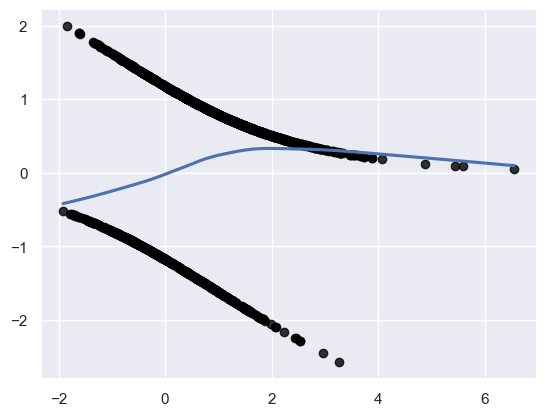

In [84]:
sns.regplot(x = log_model.fittedvalues, y = log_model.resid_dev, color = "black", line_kws = {"color" : "b"}, lowess = True)

This graph further corroborates our claim that we would use a logistic regression model for our data as our blue line is not linear at all, meaning that a linear model would not be an accurate presentation and a logistic model would work much better.